# Decision Science Lab: Causal Analytics for Retail Promotions

**Business question:** Should the retailer continue, stop, or target promotions?

This first notebook establishes the baseline descriptive analysis and shows why a naive promoted-vs-non-promoted comparison can be misleading.

## 1. Load Data

In [2]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib-cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("default")

PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "retail_promotions_synthetic.csv"

# Support running from either the repo root or the notebooks directory.
if not DATA_PATH.exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_PATH = PROJECT_ROOT / "data" / "retail_promotions_synthetic.csv"

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

In [3]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (52000, 31)


,store_id,product_id,week,region,store_size,urbanicity,baseline_demand,local_income_index,competition_intensity,category,...,promo_type,treatment_probability,units_sold,revenue,gross_profit,promo_cost,net_profit,treatment_effect_true,incremental_units_true,incremental_profit_true
0,S001,P001,1,Midwest,small,urban,48.24,106.9,0.95,snacks,...,display,0.8800,98,320.03,98.36,9.17,89.19,0.4874,32.28,-4.89
1,S001,P001,2,Midwest,small,urban,48.24,106.9,0.95,snacks,...,price_cut,0.6427,81,260.03,76.81,4.79,72.02,0.5279,30.52,-3.74
2,S001,P001,3,Midwest,small,urban,48.24,106.9,0.95,snacks,...,coupon,0.6538,88,298.09,99.04,8.55,90.49,0.3981,23.15,0.26
3,S001,P001,4,Midwest,small,urban,48.24,106.9,0.95,snacks,...,price_cut,0.6648,101,310.45,81.99,5.24,76.75,0.6280,36.72,-11.33
4,S001,P001,5,Midwest,small,urban,48.24,106.9,0.95,snacks,...,coupon,0.6738,100,305.90,79.70,9.17,70.53,0.6388,37.52,-16.13


In [4]:
df.columns.tolist()

['store_id',
 'product_id',
 'week',
 'region',
 'store_size',
 'urbanicity',
 'baseline_demand',
 'local_income_index',
 'competition_intensity',
 'category',
 'brand_tier',
 'base_price',
 'margin_rate',
 'price_elasticity',
 'baseline_popularity',
 'month',
 'season',
 'holiday_flag',
 'seasonal_demand_index',
 'promotion_flag',
 'discount_depth',
 'promo_type',
 'treatment_probability',
 'units_sold',
 'revenue',
 'gross_profit',
 'promo_cost',
 'net_profit',
 'treatment_effect_true',
 'incremental_units_true',
 'incremental_profit_true']

## 2. Sanity Checks

In [5]:
promotion_rate = df["promotion_flag"].mean()
print(f"Promotion rate: {promotion_rate:.3f}")

Promotion rate: 0.318


In [6]:
promotion_distribution = pd.DataFrame(
    {
        "row_count": df["promotion_flag"].value_counts().sort_index(),
        "share": df["promotion_flag"].value_counts(normalize=True).sort_index(),
    }
)
promotion_distribution.index = ["non_promoted", "promoted"]
promotion_distribution

,row_count,share
non_promoted,35467,0.682058
promoted,16533,0.317942


In [7]:
outcome_cols = ["units_sold", "revenue", "gross_profit", "net_profit"]
df[outcome_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
units_sold,52000.0,51.75,36.11,2.00,27.00,40.00,66.00,294.00
revenue,52000.0,223.29,108.04,19.24,147.05,198.95,273.21,1032.51
gross_profit,52000.0,73.86,40.27,3.36,47.26,64.12,89.23,484.10
net_profit,52000.0,71.46,39.51,-0.90,45.65,62.28,86.67,463.73


In [8]:
missing_values = df.isna().sum().to_frame("missing_count")
missing_values["missing_rate"] = missing_values["missing_count"] / len(df)
missing_values.query("missing_count > 0")

,missing_count,missing_rate


## 3. Naive Comparison

In [9]:
naive_group_averages = df.groupby("promotion_flag")[outcome_cols].mean().round(2)
naive_group_averages.index = ["non_promoted", "promoted"]
naive_group_averages

,units_sold,revenue,gross_profit,net_profit
non_promoted,34.58,189.40,70.88,70.88
promoted,88.59,295.99,80.24,72.70


In [10]:
naive_net_profit_diff = (
    df.loc[df["promotion_flag"].eq(1), "net_profit"].mean()
    - df.loc[df["promotion_flag"].eq(0), "net_profit"].mean()
)

print(f"Naive net_profit difference: {naive_net_profit_diff:.2f}")

Naive net_profit difference: 1.81


The naive comparison treats promoted and non-promoted rows as if they were exchangeable. In this synthetic data, that assumption is intentionally false: promotions are targeted toward rows with stronger expected demand.

## 4. Ground Truth Comparison

In [11]:
true_incremental_profit_promoted = df.loc[
    df["promotion_flag"].eq(1), "incremental_profit_true"
].mean()

bias = naive_net_profit_diff - true_incremental_profit_promoted

ground_truth_comparison = pd.DataFrame(
    {
        "metric": [
            "naive net_profit difference",
            "true incremental profit among promoted rows",
            "bias: naive minus true",
        ],
        "value": [naive_net_profit_diff, true_incremental_profit_promoted, bias],
    }
)

ground_truth_comparison["value"] = ground_truth_comparison["value"].round(2)
ground_truth_comparison

,metric,value
0,naive net_profit difference,1.81
1,true incremental profit among promoted rows,-14.59
2,bias: naive minus true,16.40


The ground truth column exists only because this is synthetic data. In a real retail setting, the analyst would observe sales and profit, but not the counterfactual profit that would have occurred without the promotion.

## 5. Visualizations

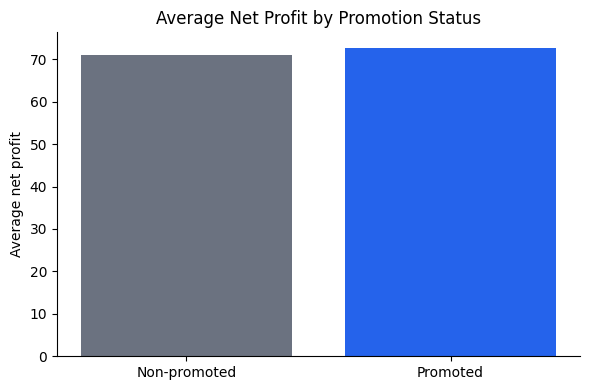

Saved: /home/wsl/Decision-Science-Lab/reports/figures/average_net_profit_by_promotion_flag.png


In [12]:
avg_net_profit = df.groupby("promotion_flag")["net_profit"].mean().reindex([0, 1])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Non-promoted", "Promoted"], avg_net_profit, color=["#6B7280", "#2563EB"])
ax.set_title("Average Net Profit by Promotion Status")
ax.set_ylabel("Average net profit")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "average_net_profit_by_promotion_flag.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

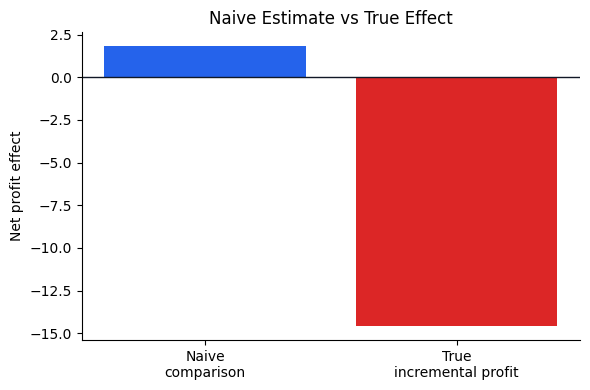

Saved: /home/wsl/Decision-Science-Lab/reports/figures/naive_estimate_vs_true_effect.png


In [13]:
estimate_values = pd.Series(
    {
        "Naive\ncomparison": naive_net_profit_diff,
        "True\nincremental profit": true_incremental_profit_promoted,
    }
)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#2563EB" if value >= 0 else "#DC2626" for value in estimate_values]
ax.bar(estimate_values.index, estimate_values.values, color=colors)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Naive Estimate vs True Effect")
ax.set_ylabel("Net profit effect")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "naive_estimate_vs_true_effect.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

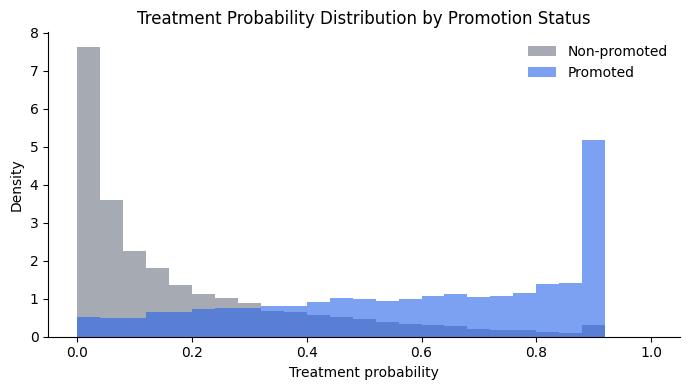

Saved: /home/wsl/Decision-Science-Lab/reports/figures/treatment_probability_distribution_by_promotion_flag.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 26)

for flag, label, color in [
    (0, "Non-promoted", "#6B7280"),
    (1, "Promoted", "#2563EB"),
]:
    ax.hist(
        df.loc[df["promotion_flag"].eq(flag), "treatment_probability"],
        bins=bins,
        alpha=0.60,
        density=True,
        label=label,
        color=color,
    )

ax.set_title("Treatment Probability Distribution by Promotion Status")
ax.set_xlabel("Treatment probability")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "treatment_probability_distribution_by_promotion_flag.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

## 6. Interpretation

The naive analysis is misleading because promotion assignment is not random. Promotions are more common in store-product-week rows that already have stronger demand signals: higher baseline demand stores, more popular products, holiday periods, seasonal periods, and strategic categories.

Selection bias appears when the promoted group has higher expected performance before the promotion effect is added. As a result, the promoted rows can show higher observed units sold, revenue, or net profit even when the promotion itself does not create that much incremental value.

In this dataset, promoted rows can look better because managers target promotions where sales were already likely to be high. The true synthetic treatment effect shows the counterfactual business impact: some promotions generate incremental profit, but others mainly discount demand that would have happened anyway or add promotion costs that outweigh the extra units sold.

This is why causal methods are needed next. The next analysis should adjust for confounding before making a decision about whether the retailer should continue, stop, or target promotions.

## 7. Causal Methods: ATT Estimates

The estimand for this first causal section is ATT-like: the average effect of promotions among rows that were actually promoted. The synthetic benchmark is the average `incremental_profit_true` among promoted rows only.

The models below use only pre-treatment covariates. Ground-truth columns, the synthetic treatment probability, and treatment-related variables such as discount depth, promotion type, promotion cost, and post-treatment outcomes are not used as model features.

In [15]:
allowed_covariates = [
    "region",
    "store_size",
    "urbanicity",
    "baseline_demand",
    "local_income_index",
    "competition_intensity",
    "category",
    "brand_tier",
    "base_price",
    "margin_rate",
    "price_elasticity",
    "baseline_popularity",
    "week",
    "month",
    "season",
    "holiday_flag",
    "seasonal_demand_index",
]

categorical_covariates = ["region", "store_size", "urbanicity", "category", "brand_tier", "season"]
numeric_covariates = [col for col in allowed_covariates if col not in categorical_covariates]

blocked_feature_cols = {
    "treatment_effect_true",
    "incremental_units_true",
    "incremental_profit_true",
    "treatment_probability",
    "discount_depth",
    "promo_type",
    "promo_cost",
}

regression_feature_cols = ["promotion_flag"] + allowed_covariates
propensity_feature_cols = allowed_covariates.copy()

leaky_regression_features = blocked_feature_cols.intersection(regression_feature_cols)
leaky_propensity_features = blocked_feature_cols.intersection(propensity_feature_cols)

assert not leaky_regression_features, leaky_regression_features
assert not leaky_propensity_features, leaky_propensity_features

print(f"Regression features: {len(regression_feature_cols)} columns before one-hot encoding")
print(f"Propensity features: {len(propensity_feature_cols)} columns before one-hot encoding")

Regression features: 18 columns before one-hot encoding
Propensity features: 17 columns before one-hot encoding


### Regression Adjustment

This model estimates `net_profit` as a function of `promotion_flag` and the allowed pre-treatment covariates. The coefficient on `promotion_flag` is the regression-adjusted promotion estimate.

In [16]:
X_regression = pd.get_dummies(
    df[regression_feature_cols],
    columns=categorical_covariates,
    drop_first=True,
    dtype=float,
)
y = df["net_profit"]

regression_model = LinearRegression()
regression_model.fit(X_regression, y)

regression_adjusted_estimate = float(
    regression_model.coef_[X_regression.columns.get_loc("promotion_flag")]
)

pd.DataFrame(
    {
        "term": ["promotion_flag"],
        "regression_adjusted_estimate": [regression_adjusted_estimate],
    }
).round(2)

,term,regression_adjusted_estimate
0,promotion_flag,-15.5


The regression-adjusted estimate compares promoted and non-promoted rows after accounting for observed pre-treatment differences. If selection bias is important, this estimate should move downward relative to the naive difference and closer to the synthetic ATT benchmark.

### Propensity Score Weighting

The propensity model estimates each row's probability of promotion using only the allowed pre-treatment covariates. For an ATT-style estimate, promoted rows keep weight 1 and non-promoted rows receive weight `p / (1 - p)`, so the weighted controls resemble the promoted rows on observed covariates.

In [17]:
X_propensity = pd.get_dummies(
    df[propensity_feature_cols],
    columns=categorical_covariates,
    drop_first=True,
    dtype=float,
)
treatment = df["promotion_flag"]

propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, solver="lbfgs"),
)
propensity_model.fit(X_propensity, treatment)

estimated_propensity_score = propensity_model.predict_proba(X_propensity)[:, 1]
df["estimated_propensity_score"] = np.clip(estimated_propensity_score, 0.02, 0.98)

df["att_weight"] = np.where(
    df["promotion_flag"].eq(1),
    1.0,
    df["estimated_propensity_score"] / (1 - df["estimated_propensity_score"]),
)

treated_mask = df["promotion_flag"].eq(1)
control_mask = ~treated_mask

treated_net_profit_mean = df.loc[treated_mask, "net_profit"].mean()
weighted_control_net_profit_mean = np.average(
    df.loc[control_mask, "net_profit"],
    weights=df.loc[control_mask, "att_weight"],
)
ps_weighted_att_estimate = treated_net_profit_mean - weighted_control_net_profit_mean

pd.DataFrame(
    {
        "metric": [
            "treated average net_profit",
            "weighted control average net_profit",
            "propensity score weighted ATT estimate",
        ],
        "value": [
            treated_net_profit_mean,
            weighted_control_net_profit_mean,
            ps_weighted_att_estimate,
        ],
    }
).round(2)

,metric,value
0,treated average net_profit,72.70
1,weighted control average net_profit,94.96
2,propensity score weighted ATT estimate,-22.27


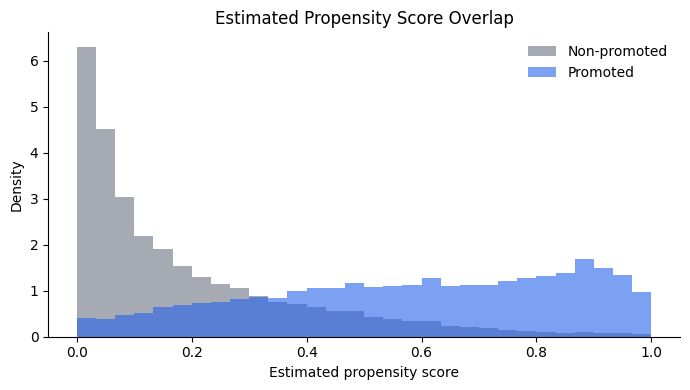

Saved: /home/wsl/Decision-Science-Lab/reports/figures/propensity_score_overlap.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 31)

for flag, label, color in [
    (0, "Non-promoted", "#6B7280"),
    (1, "Promoted", "#2563EB"),
]:
    ax.hist(
        df.loc[df["promotion_flag"].eq(flag), "estimated_propensity_score"],
        bins=bins,
        alpha=0.60,
        density=True,
        label=label,
        color=color,
    )

ax.set_title("Estimated Propensity Score Overlap")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "propensity_score_overlap.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

### Covariate Balance

Standardized mean differences compare treated rows with control rows. After ATT weighting, the weighted control group should be closer to the promoted group on key observed covariates.

In [19]:
balance_covariates = [
    "baseline_demand",
    "baseline_popularity",
    "seasonal_demand_index",
    "local_income_index",
    "competition_intensity",
    "price_elasticity",
    "margin_rate",
]


def weighted_mean(values, weights):
    return np.average(values, weights=weights)


def weighted_variance(values, weights):
    mean = weighted_mean(values, weights)
    return np.average((values - mean) ** 2, weights=weights)


def standardized_mean_difference(data, covariate, control_weight_col=None):
    treated_values = data.loc[treated_mask, covariate].to_numpy()
    control_values = data.loc[control_mask, covariate].to_numpy()

    treated_mean = treated_values.mean()
    treated_var = treated_values.var(ddof=0)

    if control_weight_col is None:
        control_mean = control_values.mean()
        control_var = control_values.var(ddof=0)
    else:
        control_weights = data.loc[control_mask, control_weight_col].to_numpy()
        control_mean = weighted_mean(control_values, control_weights)
        control_var = weighted_variance(control_values, control_weights)

    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    return (treated_mean - control_mean) / pooled_sd


balance_table = pd.DataFrame(
    {
        "covariate": balance_covariates,
        "smd_before_weighting": [
            standardized_mean_difference(df, covariate) for covariate in balance_covariates
        ],
        "smd_after_weighting": [
            standardized_mean_difference(df, covariate, "att_weight")
            for covariate in balance_covariates
        ],
    }
)
balance_table["abs_smd_before_weighting"] = balance_table["smd_before_weighting"].abs()
balance_table["abs_smd_after_weighting"] = balance_table["smd_after_weighting"].abs()

balance_table.round(3)

,covariate,smd_before_weighting,smd_after_weighting,abs_smd_before_weighting,abs_smd_after_weighting
0,baseline_demand,0.641,-0.231,0.641,0.231
1,baseline_popularity,1.017,-0.134,1.017,0.134
2,seasonal_demand_index,0.580,-0.216,0.580,0.216
3,local_income_index,-0.001,0.075,0.001,0.075
4,competition_intensity,-0.042,-0.009,0.042,0.009
5,price_elasticity,-0.630,0.050,0.630,0.050
6,margin_rate,-0.031,0.040,0.031,0.040


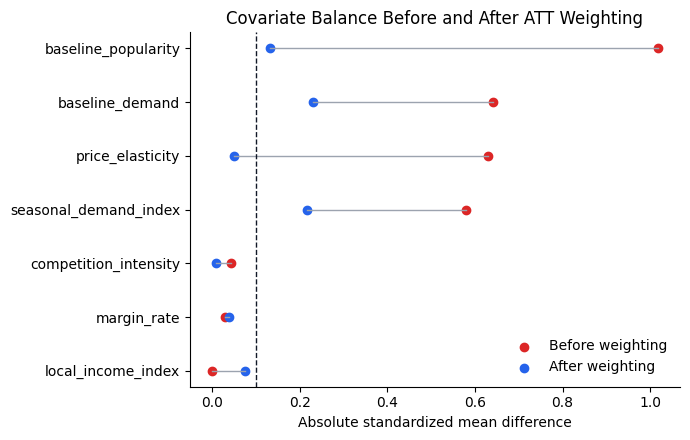

Saved: /home/wsl/Decision-Science-Lab/reports/figures/covariate_balance_before_after.png


In [20]:
plot_balance = balance_table.sort_values("abs_smd_before_weighting")
y_pos = np.arange(len(plot_balance))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(
    plot_balance["abs_smd_before_weighting"],
    y_pos,
    label="Before weighting",
    color="#DC2626",
)
ax.scatter(
    plot_balance["abs_smd_after_weighting"],
    y_pos,
    label="After weighting",
    color="#2563EB",
)
for i, row in enumerate(plot_balance.itertuples()):
    ax.plot(
        [row.abs_smd_before_weighting, row.abs_smd_after_weighting],
        [i, i],
        color="#9CA3AF",
        linewidth=1,
    )

ax.axvline(0.10, color="#111827", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_balance["covariate"])
ax.set_xlabel("Absolute standardized mean difference")
ax.set_title("Covariate Balance Before and After ATT Weighting")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "covariate_balance_before_after.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

### Final Estimate Comparison

The table below compares the naive difference, two first-pass causal estimates, and the synthetic ATT benchmark.

In [21]:
true_synthetic_att = df.loc[treated_mask, "incremental_profit_true"].mean()

estimate_comparison = pd.DataFrame(
    {
        "estimate": [
            "Naive net profit difference",
            "Regression-adjusted estimate",
            "Propensity score weighted estimate",
            "True synthetic ATT",
        ],
        "net_profit_effect": [
            naive_net_profit_diff,
            regression_adjusted_estimate,
            ps_weighted_att_estimate,
            true_synthetic_att,
        ],
    }
)
estimate_comparison["bias_vs_true_att"] = (
    estimate_comparison["net_profit_effect"] - true_synthetic_att
)
estimate_comparison.loc[
    estimate_comparison["estimate"].eq("True synthetic ATT"), "bias_vs_true_att"
] = 0.0

estimate_comparison.round(2)

,estimate,net_profit_effect,bias_vs_true_att
0,Naive net profit difference,1.81,16.40
1,Regression-adjusted estimate,-15.50,-0.92
2,Propensity score weighted estimate,-22.27,-7.68
3,True synthetic ATT,-14.59,0.00


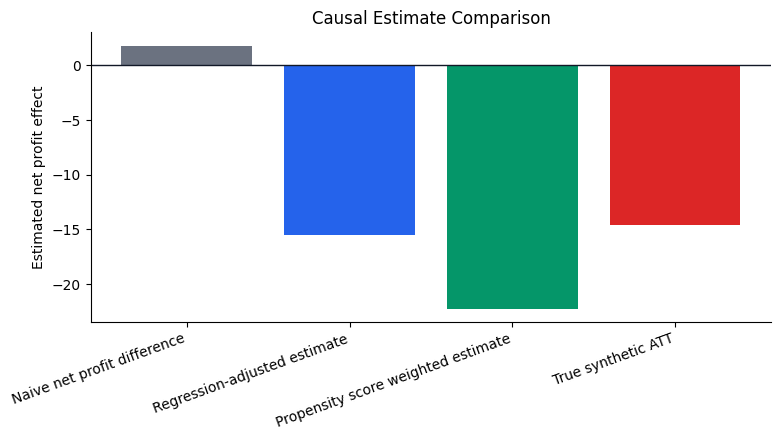

Saved: /home/wsl/Decision-Science-Lab/reports/figures/causal_estimate_comparison.png


In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(len(estimate_comparison))
colors = ["#6B7280", "#2563EB", "#059669", "#DC2626"]
ax.bar(
    x_pos,
    estimate_comparison["net_profit_effect"],
    color=colors,
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Causal Estimate Comparison")
ax.set_ylabel("Estimated net profit effect")
ax.set_xticks(x_pos)
ax.set_xticklabels(estimate_comparison["estimate"], rotation=20, ha="right")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "causal_estimate_comparison.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

The naive analysis is biased upward because the promoted group starts from a more favorable demand context. Regression adjustment and propensity score weighting use observed pre-treatment covariates to make the comparison more like-for-like, so their estimates should move closer to the synthetic ground truth than the raw promoted-minus-non-promoted difference.

The business implication is direct: blanket promotions may look profitable in descriptive reporting, but that apparent profit can be driven by targeting already-strong store-product-weeks. Once the comparison adjusts for selection bias, promotions can reveal weak or negative incremental profit, suggesting the retailer should target promotions rather than continue them broadly.